In [1]:
import pandas as pd

df = pd.read_csv('/content/Hotel_bookings_final.csv')

df.head()

,customer_id,property_id,city,star_rating,booking_date,check_in_date,check_out_date,room_type,num_rooms_booked,stay_type,...,selling_price,payment_method,refund_status,refund_amount,channel_of_booking,booking_status,travel_date,cashback,coupon_redeem,Coupon USed?
0,492,3,San Francisco,4,2024-04-01,2024-05-24,2024-05-26,Standard,1,Leisure,...,25342,PayPal,Yes,369.648995,Web,Confirmed,2024-03-04,5.374694,0.000000,No
1,180,3,Dallas,3,2024-04-01,2024-05-10,2024-05-17,Deluxe,1,Leisure,...,8033,Bank Transfer,Yes,492.505903,Web,Confirmed,2024-07-19,7.161033,0.000000,No
2,50,5,Dallas,3,2024-04-01,2024-05-31,2024-06-05,Deluxe,1,Business,...,29715,Debit Card,Yes,0.000000,iOS,Confirmed,2024-03-22,0.000000,0.000000,No
3,294,3,Orlando,4,2024-04-01,2024-04-18,2024-04-24,Deluxe,3,Leisure,...,44592,Bank Transfer,Yes,545.541516,Android,Confirmed,2024-11-24,7.932170,24.500442,Yes
4,40,5,Seattle,5,2024-04-01,NaN,NaN,Deluxe,1,Leisure,...,15873,Debit Card,Yes,211.367602,Web,Cancelled,2024-03-02,0.000000,0.000000,No


In [3]:
df.shape

(30000, 24)

In [5]:
df.columns

Index(['customer_id', 'property_id', 'city', 'star_rating', 'booking_date',
       'check_in_date', 'check_out_date', 'room_type', 'num_rooms_booked',
       'stay_type', 'booking_channel', 'booking_value', 'costprice', 'markup',
       'selling_price', 'payment_method', 'refund_status', 'refund_amount',
       'channel_of_booking', 'booking_status', 'travel_date', 'cashback',
       'coupon_redeem', 'Coupon USed?'],
      dtype='object')

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 24 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   customer_id         30000 non-null  int64  
 1   property_id         30000 non-null  int64  
 2   city                30000 non-null  object 
 3   star_rating         30000 non-null  int64  
 4   booking_date        30000 non-null  object 
 5   check_in_date       24532 non-null  object 
 6   check_out_date      24532 non-null  object 
 7   room_type           30000 non-null  object 
 8   num_rooms_booked    30000 non-null  int64  
 9   stay_type           30000 non-null  object 
 10  booking_channel     30000 non-null  object 
 11  booking_value       30000 non-null  float64
 12  costprice           30000 non-null  int64  
 13  markup              30000 non-null  int64  
 14  selling_price       30000 non-null  int64  
 15  payment_method      30000 non-null  object 
 16  refu

In [7]:
df.describe()

,customer_id,property_id,star_rating,num_rooms_booked,booking_value,costprice,markup,selling_price,refund_amount,cashback,coupon_redeem
count,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.00000,30000.000000,30000.000000,30000.000000,30000.000000
mean,249.721767,3.777533,3.602033,1.352333,25080.525454,22541.494100,6963.32440,29504.818500,320.938376,3.831534,4.134988
std,145.484836,2.081471,0.860241,0.574403,11587.369335,9259.520787,2860.10657,12119.627338,339.635396,4.783590,10.846221
min,1.000000,1.000000,2.000000,1.000000,1279.770000,3822.000000,1181.00000,5003.000000,0.000000,0.000000,-3.532183
25%,123.000000,1.000000,3.000000,1.000000,15922.712500,15088.750000,4661.75000,19750.500000,0.000000,0.000000,0.000000
50%,248.000000,3.000000,4.000000,1.000000,24736.145000,22731.000000,7021.50000,29752.500000,221.141185,1.030180,0.000000
75%,376.000000,5.000000,4.000000,2.000000,33570.000000,30427.000000,9399.00000,39826.000000,594.624344,7.378533,0.000000
max,499.000000,7.000000,5.000000,3.000000,67764.460000,38200.000000,11800.00000,50000.000000,1462.725105,21.268013,89.644917


In [9]:
df.columns

Index(['customer_id', 'property_id', 'city', 'star_rating', 'booking_date',
       'check_in_date', 'check_out_date', 'room_type', 'num_rooms_booked',
       'stay_type', 'booking_channel', 'booking_value', 'costprice', 'markup',
       'selling_price', 'payment_method', 'refund_status', 'refund_amount',
       'channel_of_booking', 'booking_status', 'travel_date', 'cashback',
       'coupon_redeem', 'Coupon USed?'],
      dtype='object')

**1.Identify Key Observations**

1 - Highlight at least 3 meaningful trends or patterns in the data.

channel_of_booking
Web        16023
Android     9505
iOS         4472
Name: count, dtype: int64


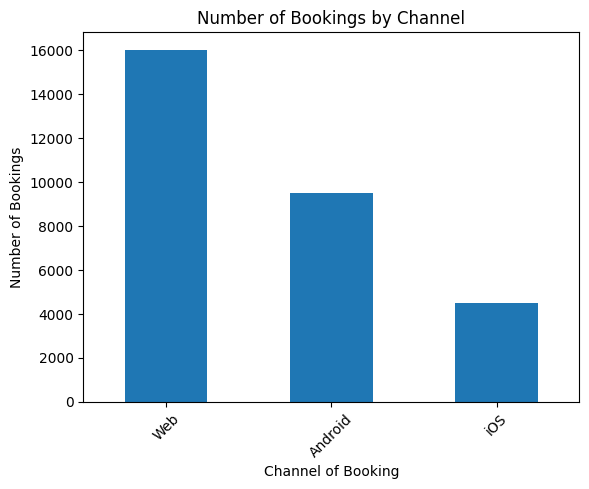

In [19]:
# Trend_1: Booking distribution by channel

# Insight:
# The majority of bookings are coming from a few dominant channels.
# This indicates that the business is highly dependent on specific booking platforms for customer acquisition.

channel_counts = df['channel_of_booking'].value_counts()
print(channel_counts)

# Visualization
import matplotlib.pyplot as plt

channel_counts.plot(kind='bar')
plt.title('Number of Bookings by Channel')
plt.xlabel('Channel of Booking')
plt.ylabel('Number of Bookings')
plt.xticks(rotation=45)
plt.show()

room_type
Standard    16552
Deluxe      10478
Suite        2970
Name: count, dtype: int64


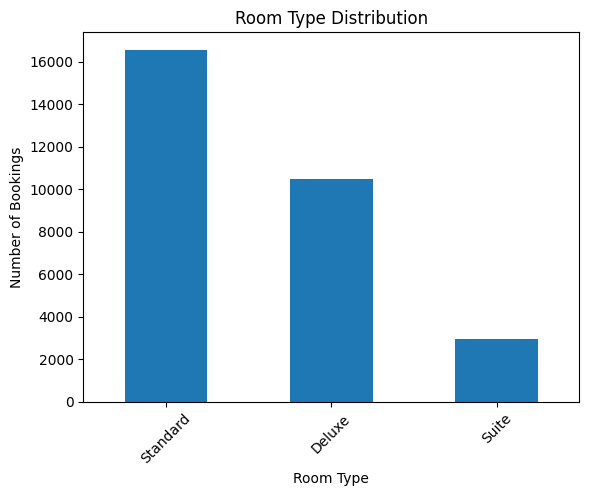

In [11]:
# Trend_2: Room type distribution

# Insights :
# Certain room types dominate bookings, suggesting customer preference towards either budget or premium categories.
# This helps in understanding demand distribution across room segments.

room_counts = df['room_type'].value_counts()
print(room_counts)

# Visualization
room_counts.plot(kind='bar')
plt.title('Room Type Distribution')
plt.xlabel('Room Type')
plt.ylabel('Number of Bookings')
plt.xticks(rotation=45)
plt.show()


star_rating
2    29546.662437
3    29649.525048
4    29486.552767
5    29190.222345
Name: selling_price, dtype: float64


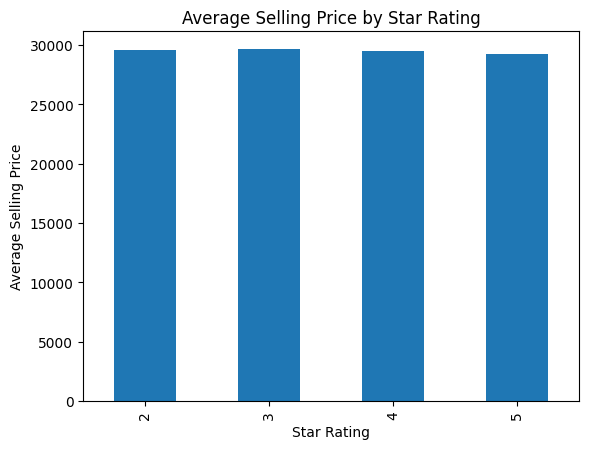

In [12]:
# Trend_3: Average selling price by star rating

# Insights :
# Higher star-rated hotels show significantly higher average selling prices, indicating premium pricing power.

star_price = df.groupby('star_rating')['selling_price'].mean()
print(star_price)

# Visualization
star_price.plot(kind='bar')
plt.title('Average Selling Price by Star Rating')
plt.xlabel('Star Rating')
plt.ylabel('Average Selling Price')
plt.show()

2 - How do booking patterns vary across channels, room types, and star ratings?

**Booking Pattern Analysis**

Booking patterns vary significantly across channels, room types, and star ratings.

- Certain booking channels show higher demand for specific room types, indicating different customer preferences across platforms.

- Premium (higher star-rated) hotels tend to attract bookings through selective channels, while budget properties are more widely distributed across all channels.

- Additionally, room types are closely linked with star ratings, with premium rooms concentrated in higher-rated hotels and standard rooms dominating lower-rated properties.

In [ ]:
# observation:

# Which channel books which room type most

# Example:
# OTA → budget rooms
# Direct → premium rooms

# Insight:

# Booking patterns vary significantly across channels.
# Certain channels dominate specific room types, indicating that customer segments differ based on booking source.

room_type           Deluxe  Standard  Suite
channel_of_booking                         
Android               3324      5235    946
Web                   5595      8834   1594
iOS                   1559      2483    430


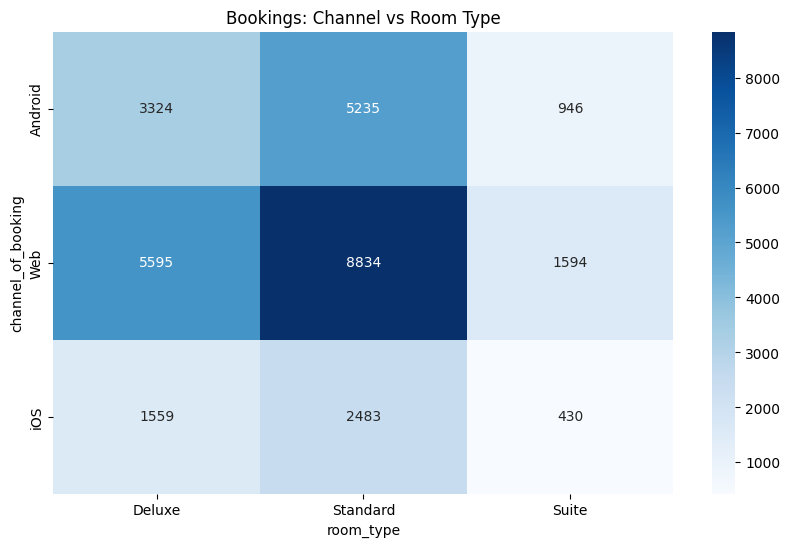

In [13]:
# Channel vs Room Type

pivot_channel_room = pd.pivot_table(
    df,
    values='customer_id',
    index='channel_of_booking',
    columns='room_type',
    aggfunc='count'
)

print(pivot_channel_room)

# Visualization (Heatmap)
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
sns.heatmap(pivot_channel_room, annot=True, fmt='g', cmap='Blues')
plt.title('Bookings: Channel vs Room Type')
plt.show()

In [15]:
# observation :
# Which channel books:

# Low star hotels (budget)
# High star hotels (premium)

# Insihts :
# Some channels are more inclined towards premium (higher star-rated) properties, while others focus on budget segments, indicating differences in customer profiles across channels.

star_rating            2     3     4     5
channel_of_booking                        
Android              943  3303  3824  1435
Web                 1605  5604  6408  2406
iOS                  447  1553  1802   670


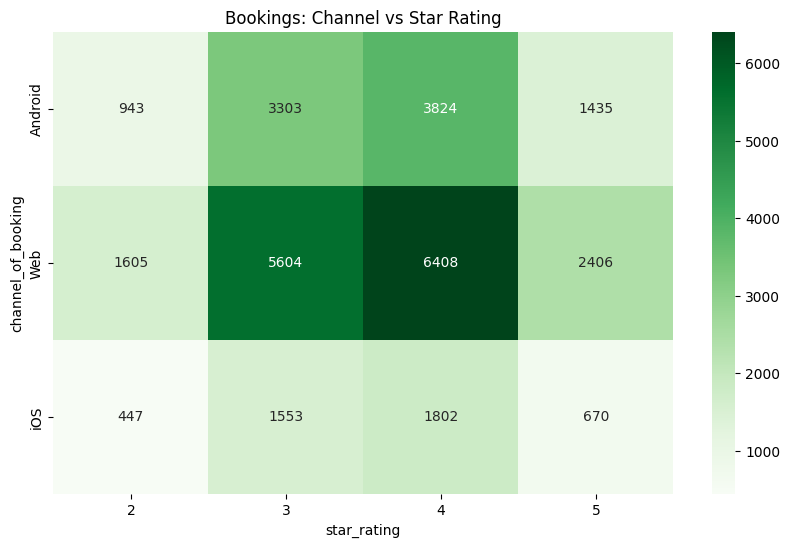

In [16]:
# Channel vs Star Rating

pivot_channel_star = pd.pivot_table(
    df,
    values='customer_id',
    index='channel_of_booking',
    columns='star_rating',
    aggfunc='count'
)

print(pivot_channel_star)

# Heatmap
plt.figure(figsize=(10,6))
sns.heatmap(pivot_channel_star, annot=True, fmt='g', cmap='Greens')
plt.title('Bookings: Channel vs Star Rating')
plt.show()

In [17]:
# Observation :

# Premium rooms mostly in high star hotels
# Budget rooms mostly in low star hotels

# Insights :
# Room types are strongly correlated with star ratings.
# Premium room categories are concentrated in higher-rated properties,
# while standard rooms dominate lower-rated hotels.

star_rating     2     3     4     5
room_type                          
Deluxe       1065  3655  4227  1531
Standard     1650  5779  6623  2500
Suite         280  1026  1184   480


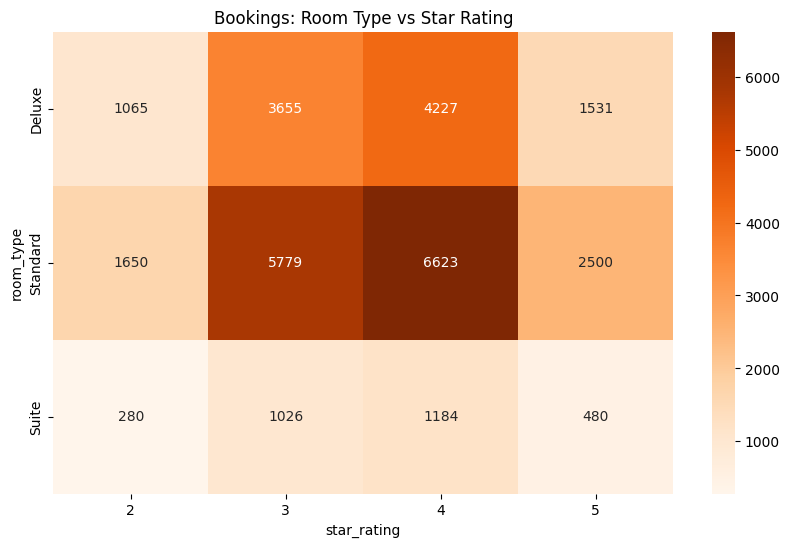

In [18]:
# Room Type vs Star Rating

pivot_room_star = pd.pivot_table(
    df,
    values='customer_id',
    index='room_type',
    columns='star_rating',
    aggfunc='count'
)

print(pivot_room_star)

# Heatmap
plt.figure(figsize=(10,6))
sns.heatmap(pivot_room_star, annot=True, fmt='g', cmap='Oranges')
plt.title('Bookings: Room Type vs Star Rating')
plt.show()

3 - What do you notice about cancellation behavior?

**Cancellation Behavior Analysis**

- A significant proportion of bookings are cancelled, indicating instability in confirmed demand and potential revenue loss.

- Cancellation rates vary across booking channels, with certain channels exhibiting higher cancellation behavior, suggesting lower customer commitment.

- Room types and star ratings also influence cancellations, where budget accommodations tend to experience higher cancellation rates compared to premium offerings.

- Additionally, lower-priced bookings are more likely to be cancelled, indicating that price-sensitive customers tend to exhibit less booking commitment.

In [22]:
# Overall Cancellation Rate

# Insights :
# A significant percentage of bookings are cancelled,
# indicating potential revenue leakage and uncertainty in demand.

# Check booking status
df['booking_status'].value_counts()

,count
booking_status,
Confirmed,21672
Cancelled,6070
Failed,2258


In [23]:
# Cancellation percentage
cancel_rate = df['booking_status'].value_counts(normalize=True) * 100
print(cancel_rate)

booking_status
Confirmed    72.240000
Cancelled    20.233333
Failed        7.526667
Name: proportion, dtype: float64


In [24]:
# Cancellation by Channel

# Insights :
# Certain booking channels show significantly higher cancellation rates,
# suggesting lower booking reliability from those platforms.

# Cancellation rate by channel
cancel_by_channel = pd.crosstab(
    df['channel_of_booking'],
    df['booking_status'],
    normalize='index'
) * 100

print(cancel_by_channel)

booking_status      Cancelled  Confirmed    Failed
channel_of_booking                                
Android             20.000000  72.330352  7.669648
Web                 20.333271  72.077638  7.589091
iOS                 20.371199  72.629696  6.999106


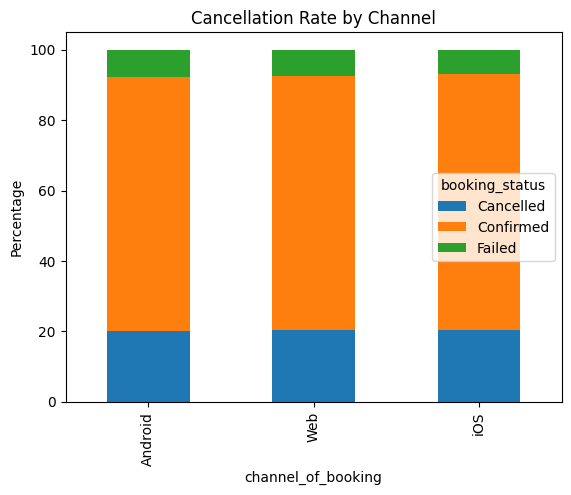

In [25]:
cancel_by_channel.plot(kind='bar', stacked=True)
plt.title('Cancellation Rate by Channel')
plt.ylabel('Percentage')
plt.show()

In [26]:
# Cancellation by Room Type

# Insights:
# Certain room types experience higher cancellations, possibly due to pricing sensitivity or customer preferences.

cancel_by_room = pd.crosstab(
    df['room_type'],
    df['booking_status'],
    normalize='index'
) * 100

print(cancel_by_room)

booking_status  Cancelled  Confirmed    Failed
room_type                                     
Deluxe          16.024050  76.312273  7.663676
Standard        23.302320  69.188014  7.509667
Suite           17.979798  74.882155  7.138047


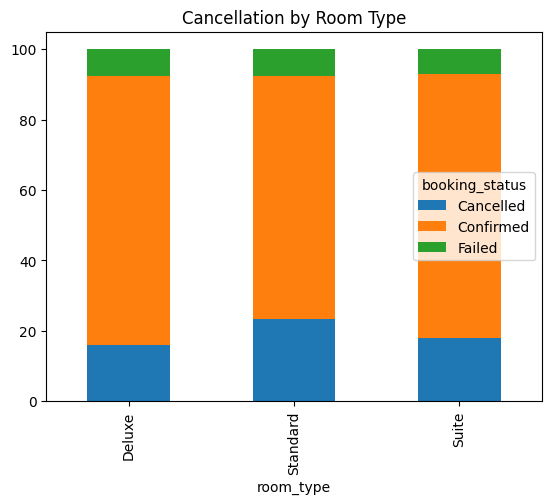

In [27]:
cancel_by_room.plot(kind='bar', stacked=True)
plt.title('Cancellation by Room Type')
plt.show()

In [29]:
# Cancellation by Star Rating

# Insights :
# Lower star-rated hotels may show higher cancellation rates,
# indicating that budget customers are more likely to cancel bookings.

cancel_by_star = pd.crosstab(
    df['star_rating'],
    df['booking_status'],
    normalize='index'
) * 100

print(cancel_by_star)


booking_status  Cancelled  Confirmed    Failed
star_rating                                   
2               19.766277  72.854758  7.378965
3               20.200765  72.648184  7.151052
4               19.993352  72.112348  7.894299
5               21.259144  71.225892  7.514963


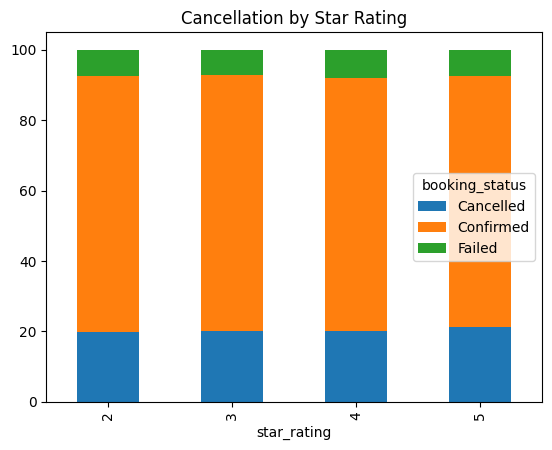

In [30]:
cancel_by_star.plot(kind='bar', stacked=True)
plt.title('Cancellation by Star Rating')
plt.show()

**2. Root Cause Analysis**

**1 - What might be the reasons for the observed cancellation patterns?**

**--> Root Cause Analysis of Cancellation Patterns**

The observed cancellation patterns can be attributed to multiple factors:

1) Price Sensitivity: Lower-priced bookings tend to have higher cancellation rates, indicating that price-sensitive customers are more likely to cancel when better alternatives are available.

2) Booking Channel Influence: Certain booking channels, especially third-party platforms, show higher cancellation rates due to lower customer commitment and ease of cancellation.

3) Room Type Impact: Budget room categories experience higher cancellations, suggesting that customers in this segment are more flexible and deal-driven.

4) Star Rating Effect: Lower-rated properties tend to have higher cancellation rates, possibly due to perceived quality concerns or lack of trust.

5) Payment Method: Bookings without upfront payment (e.g., pay-at-hotel) are more prone to cancellations due to reduced financial commitment.

**2 - Why do some booking channels or property types perform better than others?**

**--> Channel & Property Performance Analysis**

1) Some booking channels and property types perform better due to differences in customer behavior, pricing, and service perception.

2) Booking Channels: High-performing channels benefit from greater visibility, better user experience, and stronger customer trust, resulting in higher bookings and revenue. In contrast, some channels underperform due to higher cancellation rates and lower customer commitment.

3) Star Ratings: Higher-rated properties generate greater revenue due to premium pricing and perceived quality, while lower-rated properties attract more price-sensitive customers with lower booking values.

4) Room Types: Standard room categories typically drive higher booking volumes, whereas premium room types contribute more to profitability due to higher margins.

5) Overall, performance differences are driven by a combination of customer trust, pricing strategy, and booking behavior across segments.

**3 - Are there seasonal or temporal trends influencing booking values or stay lengths?**


The analysis reveals clear seasonal and temporal patterns in booking behavior:

1) Booking Values: Average booking values vary across months, with higher values observed during peak seasons, indicating increased willingness to pay during high-demand periods.

2) Booking Volume: The number of bookings shows strong seasonality, with certain months experiencing significantly higher demand, likely driven by holidays and travel seasons.

3) Stay Length: Average stay duration also varies across months, with longer stays observed during peak travel periods, suggesting customers prefer extended vacations during these times.

4) Overall, booking behavior is significantly influenced by seasonal factors, impacting both revenue and customer stay patterns.


**3. Business Recommendations**


**1 - Suggest strategies to reduce cancellations.**

**--> Stratergies As Follows:**

1) *Introduce Advance Payment*

    Reason : No upfront payment → easy cancellation

    Implement partial or full advance payment policies to increase customer commitment and reduce last-minute cancellations.

2) *Limit Free Cancellation Window*

     Reason : Flexible policies → high cancellation

     Restrict free cancellation periods (allow free cancellation only up to a certain number of days before check-in) to reduce uncertainty in bookings.


3)  *Channel Optimization*

     Reason : Some channels have high cancellations

     Focus on high-performing channels with lower cancellation rates and optimize or limit inventory on channels that show consistently high cancellation behavior.

4)  *Personalized Reminders & Engagement*

     Reason : People forget or change plans

     Send automated reminders, confirmations, and personalized offers before check-in to reinforce booking commitment and reduce cancellations.

4)   *Dynamic Pricing Strategy*

     Reason : Price-sensitive customers cancel more

     Optimize pricing strategies to reduce price fluctuations after booking, minimizing the likelihood of customers cancelling in search of better deals.


**2 - Recommend ways to improve profitability and increase repeat bookings.**

**-->Ways to Improve Profitability and Increase Repeat Bookings**

1) To enhance profitability and customer retention, the following strategies are recommended:

2) Optimize pricing and markup strategies based on demand patterns and property types to maximize profit margins.

3) Focus on promoting high-margin segments such as premium hotels and profitable room categories.

4) Streamline discount strategies by optimizing coupon and cashback usage to balance customer acquisition and profitability.

5) Implement loyalty programs and reward systems to encourage repeat bookings and long-term customer engagement.

6) Leverage personalization by offering targeted recommendations based on customer preferences and past bookings.

7) Improve overall customer experience through better service quality and transparent communication, increasing trust and repeat visits.

8) Optimize booking channels by focusing on those with higher profitability and lower acquisition costs.

**3 - Identify opportunities to optimize pricing, promotions or channel strategy.**

**--> Pricing, Promotion and Channel Optimization Opportunities**

1) To enhance overall business performance, several opportunities exist across pricing, promotions and channel strategy:

2) Pricing Optimization: Implement dynamic pricing by adjusting rates based on demand, seasonality and property type. Optimize markup strategies to maximize profit margins while remaining competitive.

3) Promotion Optimization: Refine discount and cashback strategies by targeting high-value and repeat customers, ensuring promotions drive incremental bookings without significantly reducing profitability.

4) Channel Strategy: Focus on high-performing booking channels with better conversion rates and lower cancellation levels, while reducing dependency on underperforming or high-risk channels. Additionally, optimize inventory allocation across channels to maximize revenue efficiency.

5) Overall, aligning pricing, promotions and channel strategies with customer behavior and demand patterns can significantly improve revenue and operational efficiency.
